# EN3160 - Image Processing Assignment 1

**Name:** Hasith Nettikumara  
**Index Number:** 230436X  

This notebook contains the implementations and results for Assignment 1 on intensity transformations and neighborhood filtering.

In [1]:
%pip install matplotlib opencv-python numpy


[notice] A new release of pip is available: 24.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# Folder containing the assignment images
IMAGE_DIR = Path("images")

# Check that the folder exists
print("Image directory exists:", IMAGE_DIR.exists())

Image directory exists: True


In [4]:
def show_image(image, title="", cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)

    if image.ndim == 3:
        # OpenCV loads color images in BGR format
        image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        plt.imshow(image, cmap=cmap if cmap else "gray")

    plt.title(title)
    plt.axis("off")
    plt.show()

## Question 1 - Piecewise Linear Intensity Transformation

A piecewise linear intensity transformation is applied to the given grayscale image using a set of specified breakpoints. Linear interpolation is used to determine the output intensity values between consecutive breakpoints.

In [5]:
print("Available assignment images:")

for q1_available_image_path in IMAGE_DIR.iterdir():
    print(q1_available_image_path.name)

Available assignment images:
im01.png
im01small.png
im02.png
im02small.png
im03.png
im03small.png
im04.jpg
im04small.jpg
im05.jpg
q1.jpeg
q2.jpeg
shells.tif
WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg
WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg
WhatsApp Image 2026-09-09 at 20.02.441.jpeg


In [6]:
q1_portrait_file = IMAGE_DIR / "q1.jpeg"

q1_portrait_gray = cv.imread(
    str(q1_portrait_file),
    cv.IMREAD_GRAYSCALE
)

if q1_portrait_gray is None:
    raise FileNotFoundError(
        f"Could not load Question 1 image: {q1_portrait_file}"
    )

print("Image shape:", q1_portrait_gray.shape)
print("Image datatype:", q1_portrait_gray.dtype)
print("Minimum intensity:", q1_portrait_gray.min())
print("Maximum intensity:", q1_portrait_gray.max())

Image shape: (810, 720)
Image datatype: uint8
Minimum intensity: 0
Maximum intensity: 255


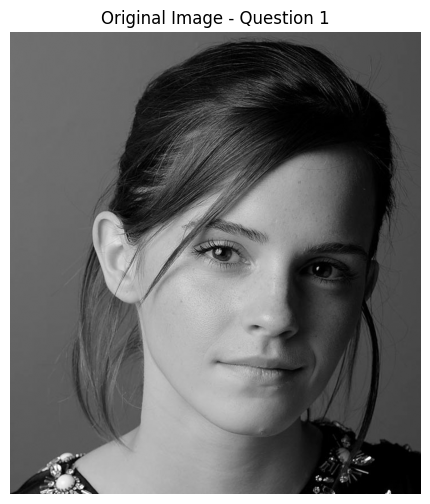

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(
    q1_portrait_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original Image - Question 1")
plt.axis("off")
plt.show()

In [8]:
q1_breakpoints_reference = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_a = np.array([
    [0,   0],
    [40,  30],
    [90,  110],
    [150, 210],
    [210, 245],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_b = np.array([
    [0,   0],
    [50,  25],
    [100, 125],
    [160, 220],
    [220, 250],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_c = np.array([
    [0,   0],
    [40,  30],
    [90,  100],
    [150, 175],
    [210, 225],
    [255, 255]
], dtype=np.float32)


q1_breakpoints_trial_d = np.array([
    [0,   0],
    [40,  28],
    [90,  98],
    [150, 168],
    [210, 222],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_e = np.array([
    [0,   0],
    [40,  32],
    [90,  102],
    [150, 170],
    [210, 220],
    [255, 255]
], dtype=np.float32)


In [9]:
def intensity_transform(im, breakpoints):
    input_levels = breakpoints[:, 0]
    output_levels = breakpoints[:, 1]

    transformed_image = np.interp(
        im.astype(np.float32),
        input_levels,
        output_levels
    )

    transformed_image = np.clip(
        transformed_image,
        0,
        255
    )

    return transformed_image.astype(np.uint8)

In [10]:
q1_output_reference = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_reference
)

q1_output_trial_a = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_a
)

q1_output_trial_b = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_b
)

q1_output_trial_c = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_c
)

q1_output_trial_d = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_d
)

q1_output_trial_e = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_e
)

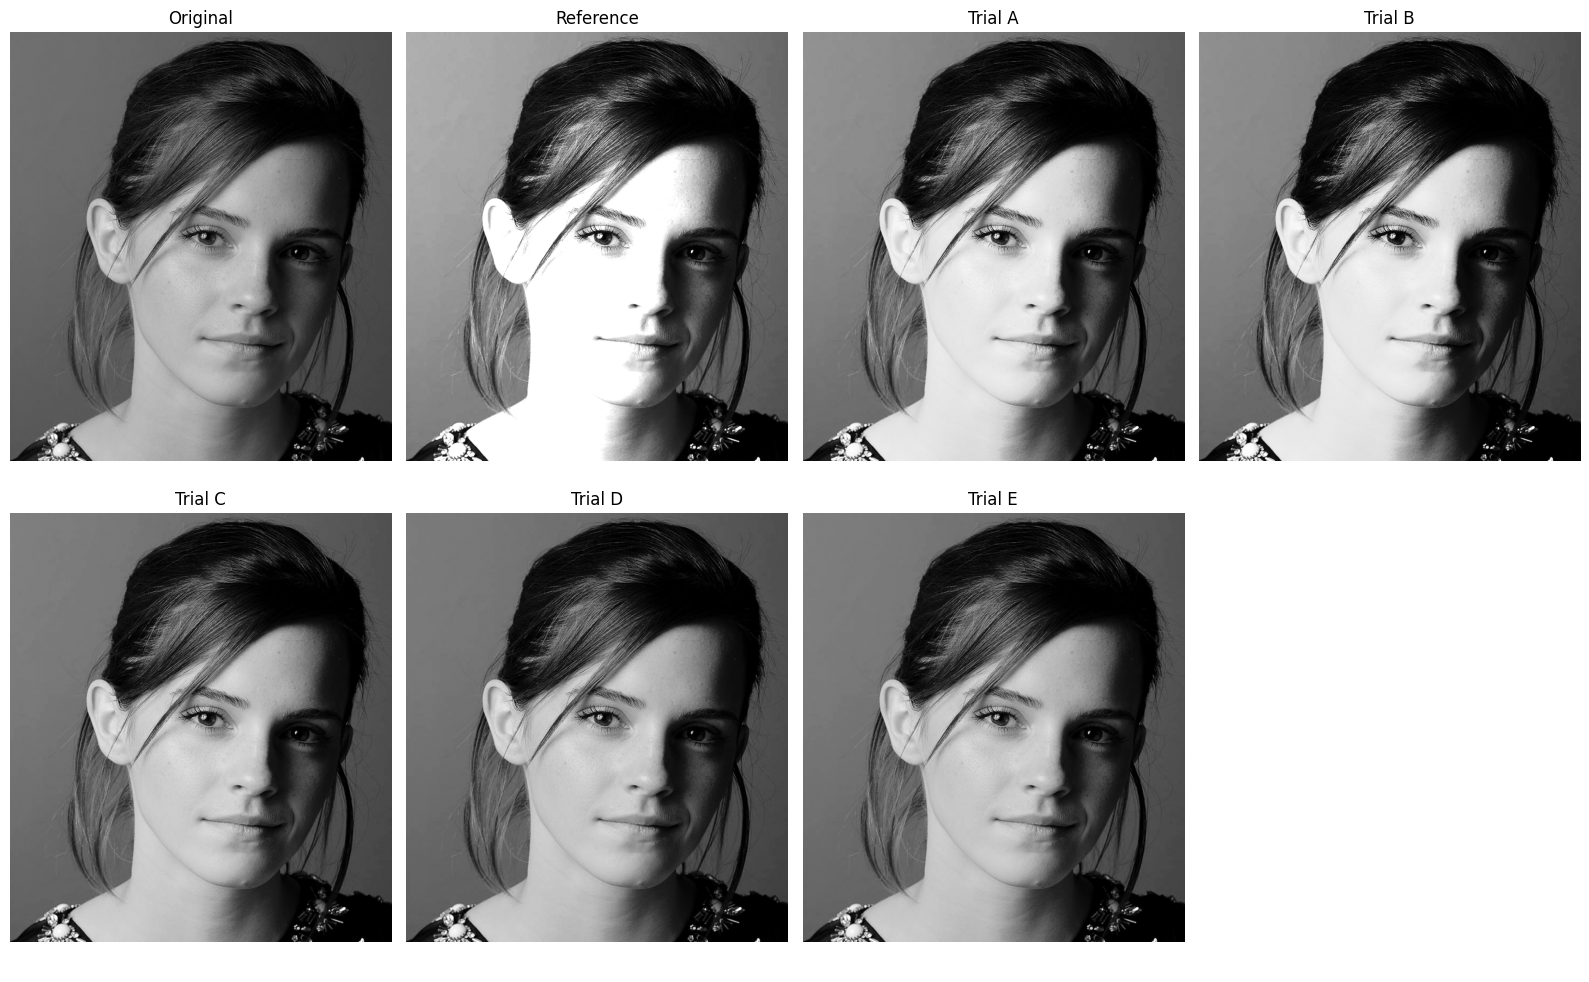

In [14]:
q1_trial_figure, q1_trial_axes = plt.subplots(
    2,
    4,
    figsize=(16, 10)
)

q1_trial_images = [
    q1_portrait_gray,
    q1_output_reference,
    q1_output_trial_a,
    q1_output_trial_b,
    q1_output_trial_c,
    q1_output_trial_d,
    q1_output_trial_e
]

q1_trial_titles = [
    "Original",
    "Reference",
    "Trial A",
    "Trial B",
    "Trial C",
    "Trial D",
    "Trial E"
]

# Flatten the 2x4 axes array so we can index it easily
q1_trial_axes_flat = q1_trial_axes.flatten()

for q1_panel_index in range(len(q1_trial_images)):

    q1_trial_axes_flat[q1_panel_index].imshow(
        q1_trial_images[q1_panel_index],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    q1_trial_axes_flat[q1_panel_index].set_title(
        q1_trial_titles[q1_panel_index]
    )

    q1_trial_axes_flat[q1_panel_index].axis("off")

# Hide the unused 8th subplot
q1_trial_axes_flat[-1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Select Trial D as the final intensity transformation
q1_selected_breakpoints = q1_breakpoints_trial_d.copy()

q1_selected_output = intensity_transform(
    q1_portrait_gray,
    q1_selected_breakpoints
)

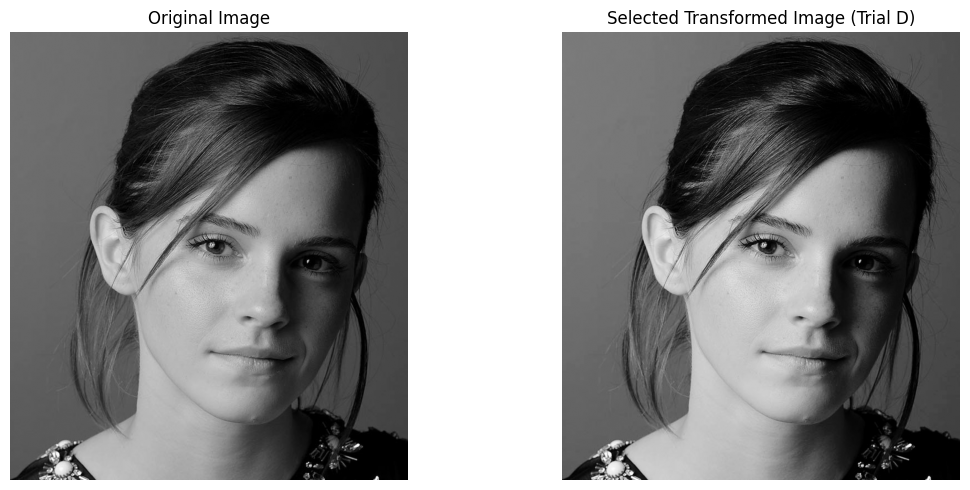

In [16]:
q1_final_figure, q1_final_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Original image
q1_final_axes[0].imshow(
    q1_portrait_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

q1_final_axes[0].set_title("Original Image")
q1_final_axes[0].axis("off")


# Selected transformed image - Trial D
q1_final_axes[1].imshow(
    q1_selected_output,
    cmap="gray",
    vmin=0,
    vmax=255
)

q1_final_axes[1].set_title("Selected Transformed Image (Trial D)")
q1_final_axes[1].axis("off")

plt.tight_layout()
plt.show()

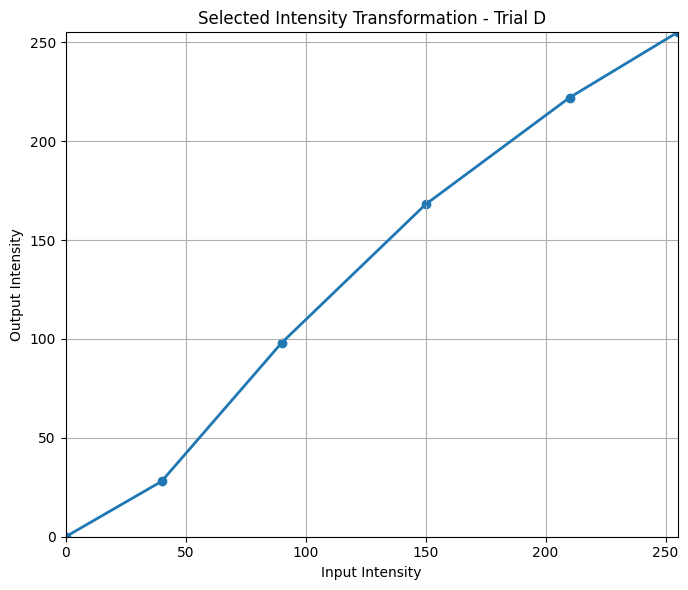

In [17]:
q1_selected_intensity_axis = np.arange(256)

q1_selected_mapping = np.interp(
    q1_selected_intensity_axis,
    q1_selected_breakpoints[:, 0],
    q1_selected_breakpoints[:, 1]
)

plt.figure(figsize=(7, 6))

plt.plot(
    q1_selected_intensity_axis,
    q1_selected_mapping,
    linewidth=2
)

plt.scatter(
    q1_selected_breakpoints[:, 0],
    q1_selected_breakpoints[:, 1]
)

plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("Selected Intensity Transformation - Trial D")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()